In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_context("paper", font_scale=1.3)

from src.data_models.caravanify import Caravanify, CaravanifyConfig

---

In [2]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

caravan = Caravanify(config)

all_basin_ids = caravan.get_all_gauge_ids()
caravan.load_stations(all_basin_ids)

static_data = caravan.get_static_attributes()


ts_data = caravan.get_time_series()[
    ["gauge_id", "date", "temperature_2m_mean", "total_precipitation_sum", "streamflow"]
]

# Drop rows with NaN values
ts_data = ts_data.dropna()

static_data.head()

,gauge_id,area,country,gauge_lat,gauge_lon,gauge_name,aet_mm_s01,aet_mm_s02,aet_mm_s03,aet_mm_s04,...,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
0,CA_15013,254.786460,Kyrgyzstan,42.652788,78.921090,15013_Kyrgyzstan,0.574803,1.858523,13.705932,35.421733,...,0.035202,3.227445,0.555020,0.251483,0.589364,2.243786,2.178943,1.192798,1.141084,0.795366
1,CA_15016,330.553623,Kyrgyzstan,42.585012,78.883448,15016_Kyrgyzstan,0.436708,0.877056,10.758896,32.752111,...,0.025684,2.860555,0.484094,0.695427,0.758767,2.835258,1.220026,0.926226,0.693118,0.474648
2,CA_15020,310.918652,Kyrgyzstan,42.471215,78.531209,15020_Kyrgyzstan,0.034713,0.496307,9.859397,31.402012,...,0.023598,2.607448,0.438201,0.789998,0.803484,3.604888,1.148668,0.957226,0.583906,0.390540
3,CA_15022,204.078792,Kyrgyzstan,42.467058,78.537862,15022_Kyrgyzstan,0.030236,1.026004,10.086078,32.057409,...,0.022164,2.675425,0.451369,0.750376,0.780492,3.267226,1.204651,0.964687,0.627135,0.418075
4,CA_15025,318.622912,Kyrgyzstan,42.424441,78.434206,15025_Kyrgyzstan,0.447321,1.103616,10.419676,30.914526,...,0.024250,2.578210,0.431943,0.782148,0.799853,3.717301,1.219889,0.991977,0.611725,0.392526


In [3]:
gdf = caravan.get_shapefiles()

gdf.head()

,gauge_id,geometry
0,CA_15013,"POLYGON ((78.98551 42.67817, 78.98792 42.67796..."
1,CA_15016,"POLYGON ((78.92975 42.59671, 78.93336 42.59639..."
2,CA_15020,"POLYGON ((78.52708 42.47201, 78.53308 42.47151..."
3,CA_15022,"POLYGON ((78.6156 42.47085, 78.6168 42.47074, ..."
4,CA_15025,"POLYGON ((78.4813 42.45065, 78.4825 42.45055, ..."


In [4]:
# Get the gauge_ids from static data where the country column is Kyrgyzstan
kgz_ids = static_data[static_data["country"] == "Kyrgyzstan"]["gauge_id"].unique()
print(f"Number of gauges in Kyrgyzstan: {len(kgz_ids)}")

# Same for Tajikistan
tjk_ids = static_data[static_data["country"] == "Tajikistan"]["gauge_id"].unique()
print(f"Number of gauges in Tajikistan: {len(tjk_ids)}")

# Add country column to gdf by mapping the gauge_id to the country
gdf["country"] = gdf["gauge_id"].map(
    static_data.set_index("gauge_id")["country"]
)

# Drop rows with NaN values in the country column
gdf = gdf[gdf["country"].notna()]

gdf


Number of gauges in Kyrgyzstan: 62
Number of gauges in Tajikistan: 16


,gauge_id,geometry,country
0,CA_15013,"POLYGON ((78.98551 42.67817, 78.98792 42.67796...",Kyrgyzstan
1,CA_15016,"POLYGON ((78.92975 42.59671, 78.93336 42.59639...",Kyrgyzstan
2,CA_15020,"POLYGON ((78.52708 42.47201, 78.53308 42.47151...",Kyrgyzstan
3,CA_15022,"POLYGON ((78.6156 42.47085, 78.6168 42.47074, ...",Kyrgyzstan
4,CA_15025,"POLYGON ((78.4813 42.45065, 78.4825 42.45055, ...",Kyrgyzstan
...,...,...,...
74,CA_17325,"POLYGON ((68.29214 39.32245, 68.29562 39.32247...",Tajikistan
75,CA_17329,"POLYGON ((69.64797 39.28405, 69.65029 39.28404...",Tajikistan
76,CA_17338,"POLYGON ((68.29214 39.32245, 68.29562 39.32247...",Tajikistan
77,CA_17344,"POLYGON ((67.71367 39.48959, 67.71948 39.48966...",Tajikistan


In [5]:
ts_data["country"] = ts_data["gauge_id"].map(
    static_data.set_index("gauge_id")["country"]
)

ts_data.head()


ts_data["date"] = pd.to_datetime(ts_data["date"])
ts_data["month"] = ts_data["date"].dt.month


In [6]:
ts_data

,gauge_id,date,temperature_2m_mean,total_precipitation_sum,streamflow,country,month
0,CA_15013,2000-01-02,-10.18,5.97,0.63,Kyrgyzstan,1
1,CA_15013,2000-01-03,-8.43,20.43,0.63,Kyrgyzstan,1
2,CA_15013,2000-01-04,-9.37,20.20,0.63,Kyrgyzstan,1
3,CA_15013,2000-01-05,-10.44,1.24,0.63,Kyrgyzstan,1
4,CA_15013,2000-01-06,-13.20,0.04,0.63,Kyrgyzstan,1
...,...,...,...,...,...,...,...
711482,CA_17462,2022-12-27,-22.20,0.01,0.50,Kyrgyzstan,12
711483,CA_17462,2022-12-28,-21.46,0.04,0.50,Kyrgyzstan,12
711484,CA_17462,2022-12-29,-19.02,0.42,0.50,Kyrgyzstan,12
711485,CA_17462,2022-12-30,-19.11,0.48,0.50,Kyrgyzstan,12


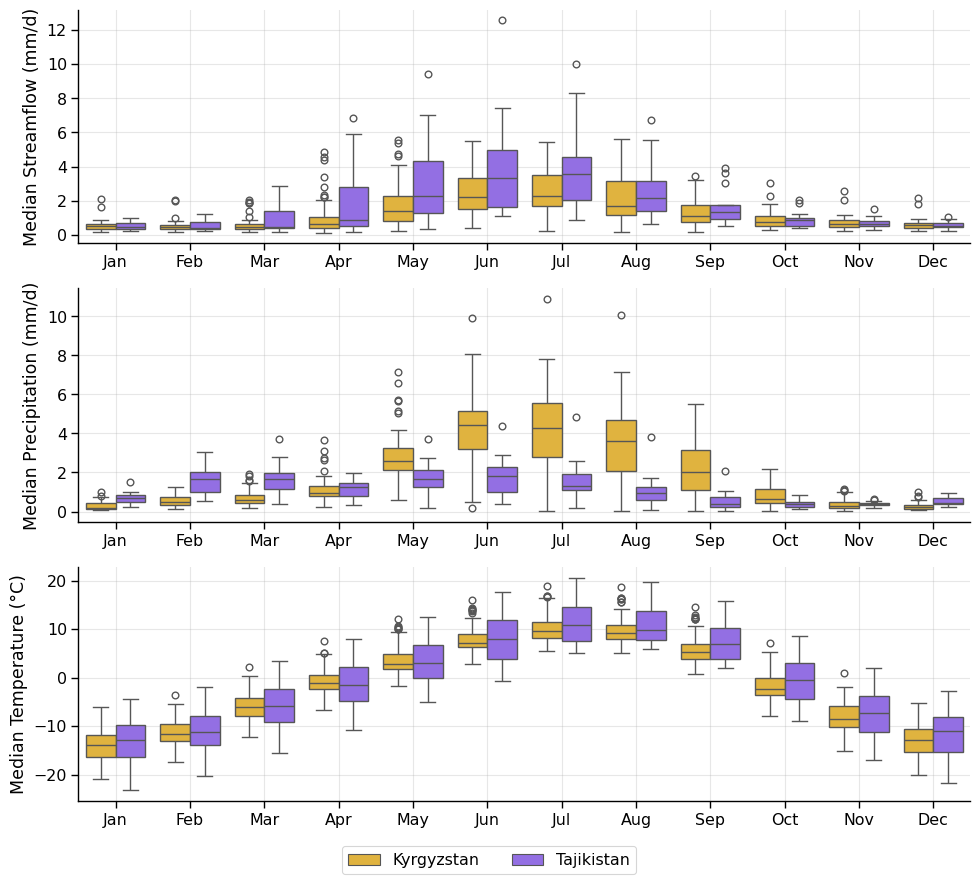

In [7]:
monthly_medians = ts_data.groupby(['gauge_id', 'country', 'month']).agg({
    'streamflow': 'median',
    'total_precipitation_sum': 'median',
    'temperature_2m_mean': 'median'
}).reset_index()


palette = ["#FBBF24", "#8B5CF6"]

# Set the figure size for better visibility
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

# Create boxplot for streamflow
streamflow_plot = sns.boxplot(x='month', y='streamflow', hue='country', data=monthly_medians, 
                             palette=palette, ax=axes[0], legend=False)
# Set alpha for all patch elements after plotting
for patch in streamflow_plot.artists:
    patch.set_alpha(0.8)

axes[0].set_xlabel('')
axes[0].set_ylabel('Median Streamflow (mm/d)')
axes[0].set_xticks(np.arange(0, 12))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].grid(True, linestyle='-', alpha=0.3)

# Create boxplot for precipitation
precip_plot = sns.boxplot(x='month', y='total_precipitation_sum', hue='country', data=monthly_medians, 
                         palette=palette, ax=axes[1], legend=False)
# Set alpha for all patch elements after plotting
for patch in precip_plot.artists:
    patch.set_alpha(0.8)

axes[1].set_xlabel('')
axes[1].set_ylabel('Median Precipitation (mm/d)')
axes[1].set_xticks(np.arange(0, 12))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].grid(True, linestyle='-', alpha=0.3)

# Create boxplot for temperature
temp_plot = sns.boxplot(x='month', y='temperature_2m_mean', hue='country', data=monthly_medians, 
                       palette=palette, ax=axes[2])
# Set alpha for all patch elements after plotting
for patch in temp_plot.artists:
    patch.set_alpha(0.8)

axes[2].set_xlabel('')
axes[2].set_ylabel('Median Temperature (°C)')
axes[2].set_xticks(np.arange(0, 12))
axes[2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[2].grid(True, linestyle='-', alpha=0.3)

# Get the legend from the last plot and place it at the bottom
handles, labels = axes[2].get_legend_handles_labels()
axes[2].get_legend().remove()

# Add a single legend at the bottom of the figure
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, 0.01))

# Adjust spacing to make room for the legend at the bottom
plt.tight_layout(rect=[0, 0.05, 1, 1])
sns.despine()

path_to_save = "/Users/cooper/Desktop/CAMELS-CH/images/CA_climate/climate_boxplots.png"
plt.savefig(path_to_save, dpi=300, bbox_inches='tight')

plt.show()

## Time for some tables

In [13]:
# Get unique countries from your dataframe
countries = static_data["country"].unique()

# Define attributes of interest
statics_of_interest = [
   #  "p_mean",
   #  "pet_mean_FAO_PM",
    "frac_snow",
   #  "aridity_FAO_PM",
    # "seasonality_ERA5_LAND",
    "area",
    "ele_mt_sav",
]

# Create a dictionary to store data from each country
country_data = {}

for country in countries:
    # Filter data by country
    country_ids = static_data[static_data["country"] == country]["gauge_id"].tolist()
    country_static = static_data[static_data["country"] == country][statics_of_interest]

    # Store the data
    country_data[country] = country_static

# Create DataFrame for results
results = pd.DataFrame(index=countries)

# Calculate statistics for attributes
for attr in statics_of_interest:
    stats = static_data.groupby("country")[attr].agg(["mean", "std"])

    formatted_stats = stats.apply(
        lambda row: f"{row['mean']:.1f} ± {row['std']:.1f}", axis=1
    )

    results[attr] = formatted_stats

# Add number of stations column
for country in countries:
    country_ids = static_data[static_data["country"] == country]["gauge_id"].tolist()
    results.at[country, "number_of_stations"] = len(country_ids)

print(results)

# Optional: Save results to CSV
# results.to_csv('country_statistics.csv')

            frac_snow             area      ele_mt_sav  number_of_stations
Kyrgyzstan  0.4 ± 0.1  1868.4 ± 6040.9  2917.8 ± 461.1                62.0
Tajikistan  0.6 ± 0.1  5029.8 ± 5681.3  3117.6 ± 625.6                16.0


In [11]:
list(static_data.columns)

['gauge_id',
 'area',
 'country',
 'gauge_lat',
 'gauge_lon',
 'gauge_name',
 'aet_mm_s01',
 'aet_mm_s02',
 'aet_mm_s03',
 'aet_mm_s04',
 'aet_mm_s05',
 'aet_mm_s06',
 'aet_mm_s07',
 'aet_mm_s08',
 'aet_mm_s09',
 'aet_mm_s10',
 'aet_mm_s11',
 'aet_mm_s12',
 'aet_mm_syr',
 'area_fraction_used_for_aggregation',
 'ari_ix_sav',
 'cls_cl_smj',
 'cly_pc_sav',
 'clz_cl_smj',
 'cmi_ix_s01',
 'cmi_ix_s02',
 'cmi_ix_s03',
 'cmi_ix_s04',
 'cmi_ix_s05',
 'cmi_ix_s06',
 'cmi_ix_s07',
 'cmi_ix_s08',
 'cmi_ix_s09',
 'cmi_ix_s10',
 'cmi_ix_s11',
 'cmi_ix_s12',
 'cmi_ix_syr',
 'crp_pc_sse',
 'dis_m3_pmn',
 'dis_m3_pmx',
 'dis_m3_pyr',
 'dor_pc_pva',
 'ele_mt_sav',
 'ele_mt_smn',
 'ele_mt_smx',
 'ero_kh_sav',
 'fec_cl_smj',
 'fmh_cl_smj',
 'for_pc_sse',
 'gdp_ud_sav',
 'gdp_ud_ssu',
 'gla_pc_sse',
 'glc_cl_smj',
 'glc_pc_s01',
 'glc_pc_s02',
 'glc_pc_s03',
 'glc_pc_s04',
 'glc_pc_s05',
 'glc_pc_s06',
 'glc_pc_s07',
 'glc_pc_s08',
 'glc_pc_s09',
 'glc_pc_s10',
 'glc_pc_s11',
 'glc_pc_s12',
 'glc_pc_s13',